# Exploration of Specific Categories within the Taxonomy

## Goals

- Visualize how categories are connected in parent-children relationships
- Check consistency and correctness of category relationships (easier to see in a graph)

## Interesting Categories:

- Sweet Spreads
- Honeys
- Milks
- Salty Snacks
- Bars

## Approach

1. Load Category Taxonomy via Python library (see also [https://github.com/openfoodfacts/openfoodfacts-python/blob/develop/docs/handle_taxonomies.md](handle taxonomies))
2. Create Taxonomy Graph (for English categories)
3. Select Sub-Graph and convert to Dot format
4. Render Graph from Dot description

In [1]:
from IPython.display import Image
from openfoodfacts.taxonomy import get_taxonomy, Taxonomy
from networkx.drawing.nx_pydot import to_pydot
import networkx as nx
import pandas as pd
import pydot

## Load Category Taxonomy

In [2]:
categories: Taxonomy = get_taxonomy("category", download_newer=True)
print(f"{len(categories):,} categories")

/Users/goerlitz/.cache/openfoodfacts/taxonomy/category.json: 100%|██████████| 6.39M/6.39M [00:00<00:00, 12.4MB/s]


14,180 categories


## Create Taxonomy Graph

- use parent relationship of taxonomy entries
- filter categories in English language

In [3]:
G = nx.DiGraph();


for node in categories.iter_nodes():
  # ignore non-English categories
  if not node.id.startswith('en:'):
    continue

  for parent in node.parents:
    if not parent.id.startswith('en:'):
      print(f"parent {parent.id} of {node.id} is not in English")
      continue
  
    G.add_edge(parent.id.replace(':', '.'), node.id.replace(':', '.'))

print(f"#Nodes: {len(G.nodes):,}")
print(f"#Edges: {len(G.edges):,}")

parent xx:liverwurst of en:liverwurst-sausages is not in English
parent fr:gateaux-de-semoule of en:refrigerated-semolina-pudding is not in English
parent xx:liverwurst of en:liverwurst-spreads is not in English
parent fr:marc of en:french-grape-marc-spirit-or-grape-marc is not in English
parent ca:cervesa-ipa of en:fruit-ipa is not in English
parent fr:quenelles of en:plain-quenelles is not in English
parent fr:merguez of en:beef-merguez is not in English
parent ca:cervesa-ipa of en:hurricane-ipa is not in English
parent ca:cervesa-ipa of en:summer-ipa is not in English
parent de:obstbrand of en:hungarian-fruit-spirit is not in English
parent xx:tangyuan of en:frozen-tangyuan is not in English
parent fr:charcuteries-cuites of en:morteaux-sausage-boiled-in-water is not in English
parent xx:varenyky of en:frozen-varenyky is not in English
parent fr:allumettes-de-volaille of en:minced-turkey-ham is not in English
parent fr:fromages-blancs of en:fresh-cream-cheese-with-cow-s-milk is not i

In [4]:
categories['en:sweet-spreads'].children

[<TaxonomyNode fr:cremes-de-pistaches>,
 <TaxonomyNode en:sweet-spread-variety-packs>,
 <TaxonomyNode en:speculoos-spreads>,
 <TaxonomyNode en:honey-based-preparations>,
 <TaxonomyNode en:almond-spreads>,
 <TaxonomyNode en:chocolate-spreads>,
 <TaxonomyNode en:ginger-preserves>,
 <TaxonomyNode en:honeys>,
 <TaxonomyNode en:fruit-curds>,
 <TaxonomyNode en:thick-syrups>,
 <TaxonomyNode en:wine-spreads>,
 <TaxonomyNode fr:pates-a-tartiner>,
 <TaxonomyNode en:carob-spreads>,
 <TaxonomyNode en:milk-jams>,
 <TaxonomyNode en:flower-preserves>,
 <TaxonomyNode en:caramel-spreads>,
 <TaxonomyNode en:fruit-and-vegetable-preserves>,
 <TaxonomyNode en:hazelnut-spreads>,
 <TaxonomyNode en:confectionary-based-spreads>,
 <TaxonomyNode en:beer-spreads>]

In [5]:
G['en.sweet-spreads']

AtlasView({'en.sweet-spread-variety-packs': {}, 'en.speculoos-spreads': {}, 'en.honey-based-preparations': {}, 'en.almond-spreads': {}, 'en.chocolate-spreads': {}, 'en.ginger-preserves': {}, 'en.honeys': {}, 'en.fruit-curds': {}, 'en.thick-syrups': {}, 'en.wine-spreads': {}, 'en.carob-spreads': {}, 'en.milk-jams': {}, 'en.flower-preserves': {}, 'en.caramel-spreads': {}, 'en.fruit-and-vegetable-preserves': {}, 'en.hazelnut-spreads': {}, 'en.confectionary-based-spreads': {}, 'en.beer-spreads': {}})

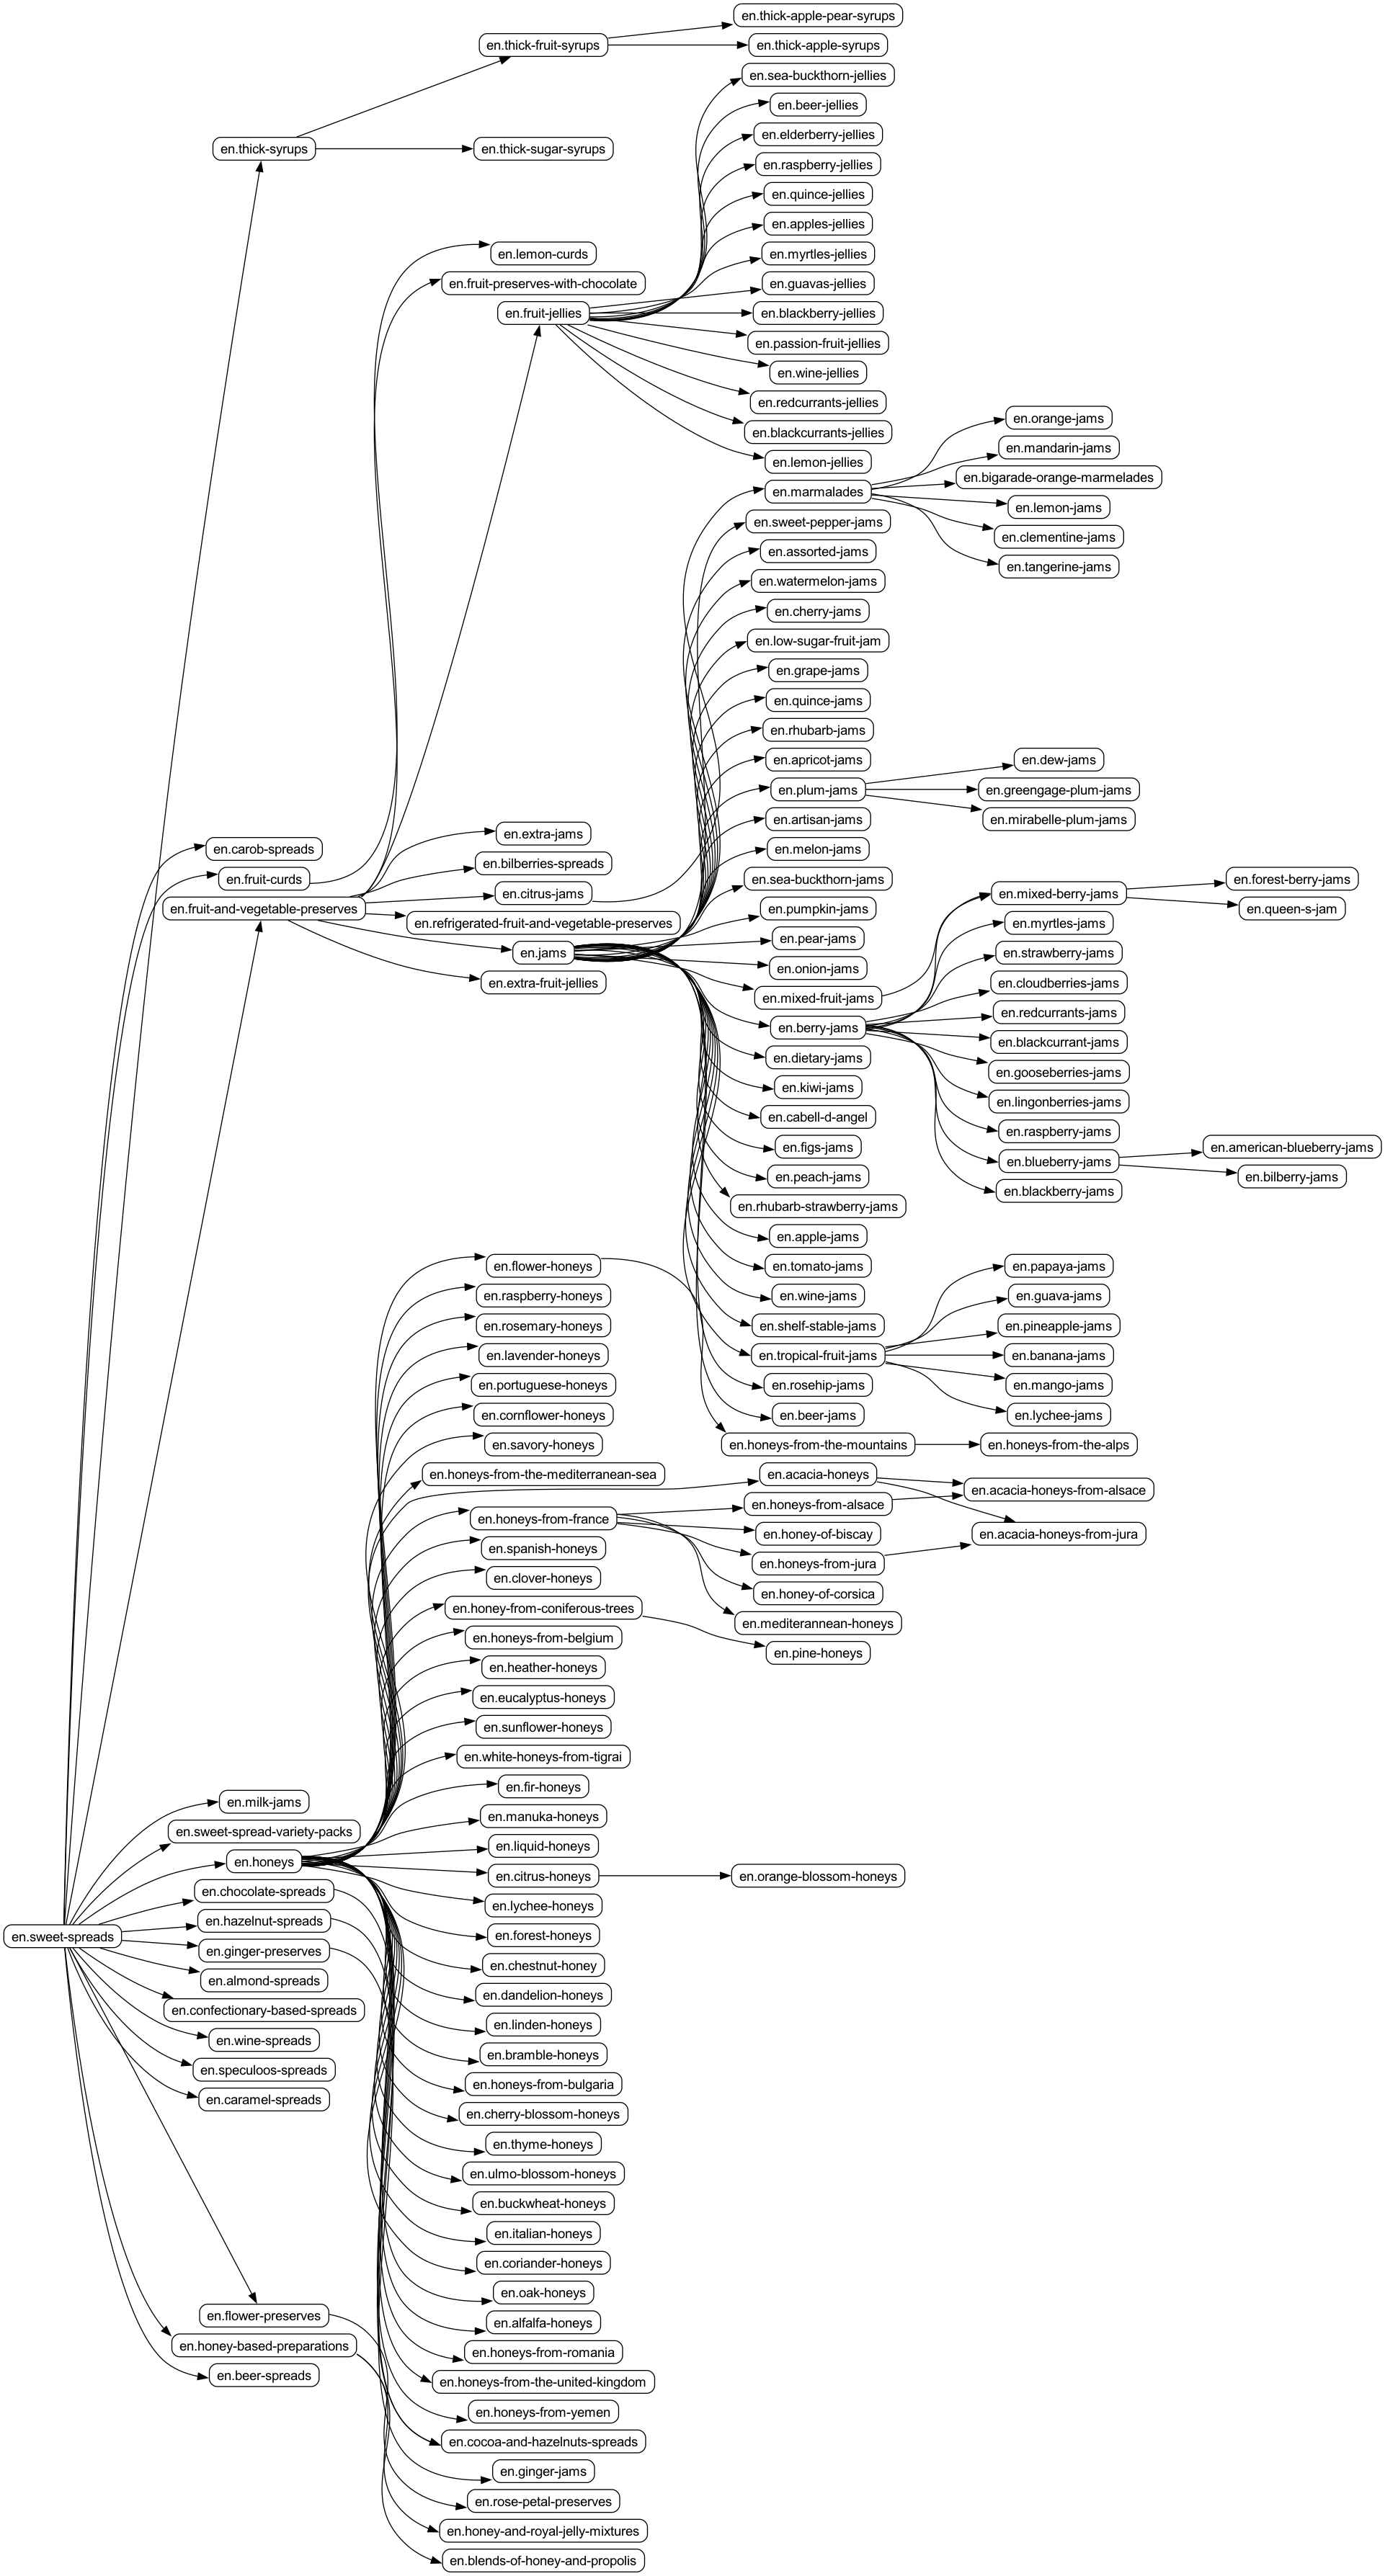

In [6]:
cat_name = 'en.sweet-spreads'
descendants = nx.descendants(G, cat_name)

subG = G.subgraph(descendants | {cat_name})

# Set node style attributes
for node in subG.nodes:
    subG.nodes[node]['shape'] = 'box'
    subG.nodes[node]['style'] = 'rounded'


P = to_pydot(subG)
P.set('rankdir', 'LR') # left to right
P.set('nodesep', 0.1)
P.set('ranksep', 0.6)


for node in P.get_nodes():
    # node.set('fontsize', '10')
    node.set('fontname', 'Arial')
    node.set_height(0)
    # node.set('margin', '0.1,0.1')

Image(P.create_png())

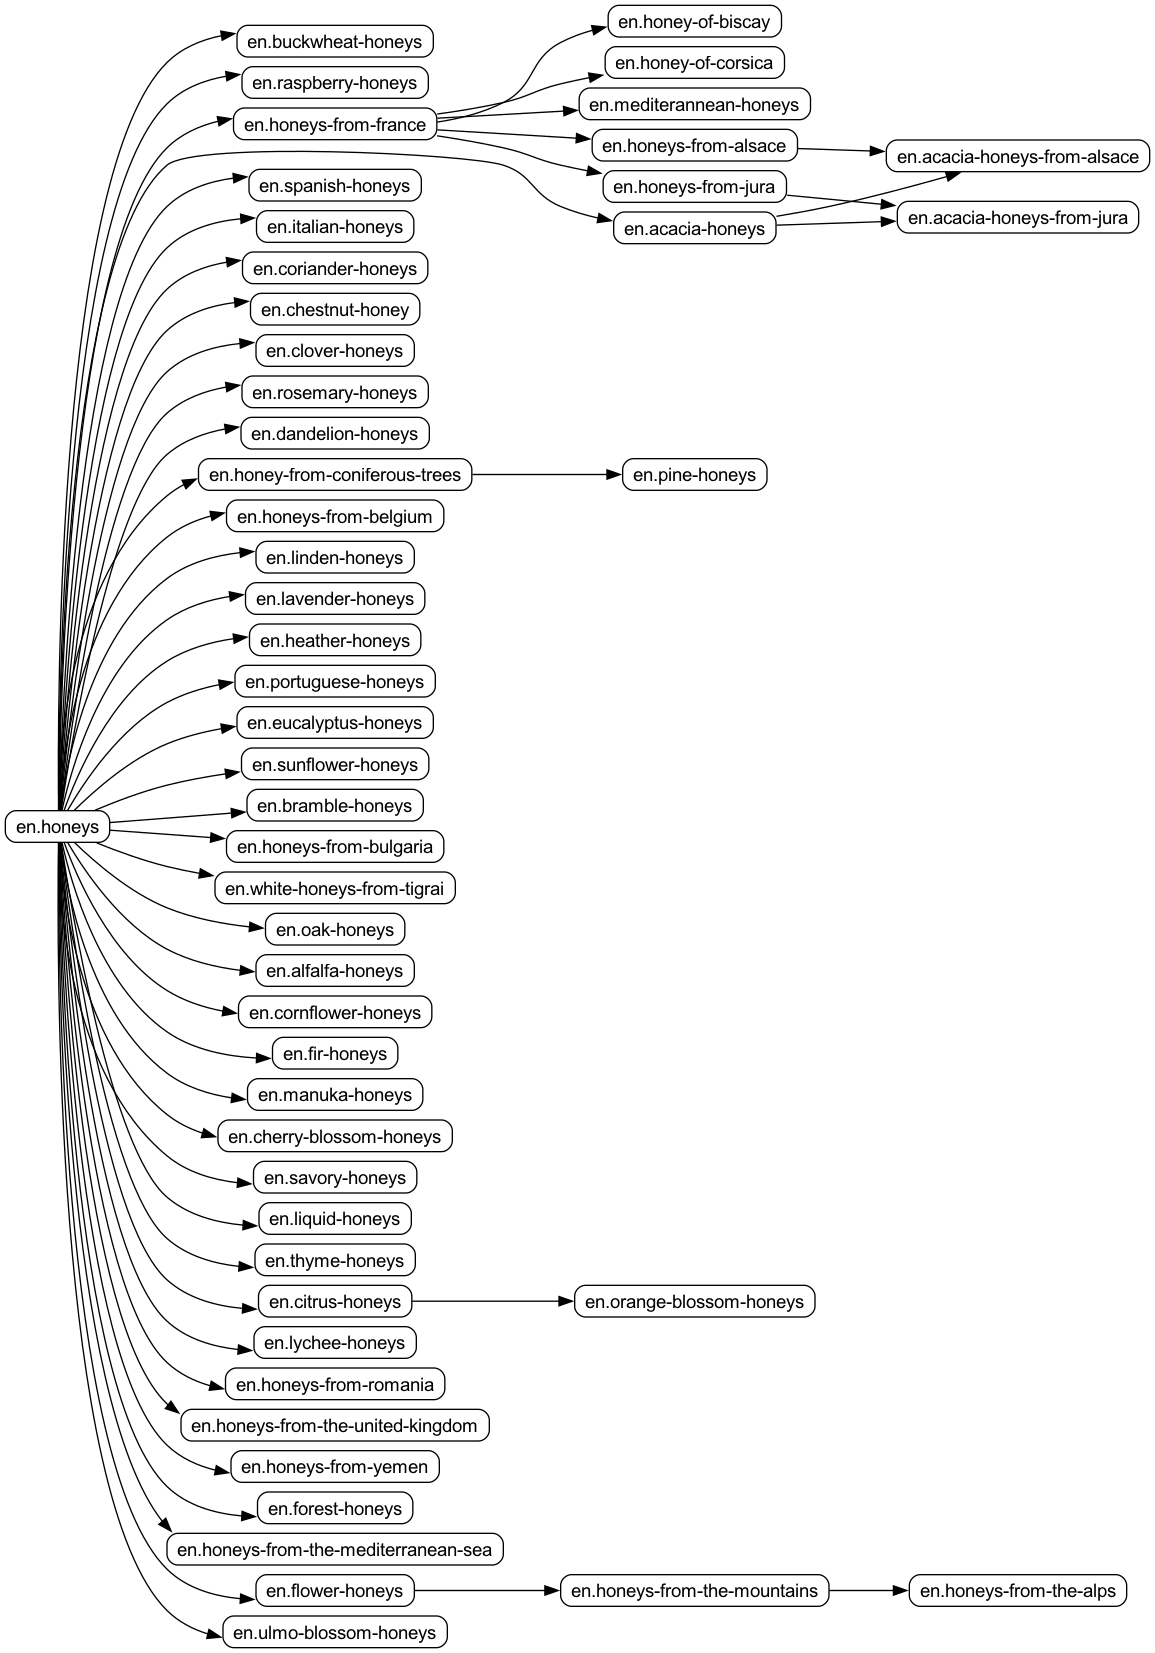

In [7]:
cat_name = 'en.honeys'
descendants = nx.descendants(G, cat_name)

subG = G.subgraph(descendants | {cat_name})

# Set node style attributes
for node in subG.nodes:
    subG.nodes[node]['shape'] = 'box'
    subG.nodes[node]['style'] = 'rounded'


P = to_pydot(subG)
P.set('rankdir', 'LR') # left to right
P.set('nodesep', 0.1)
P.set('ranksep', 0.6)


for node in P.get_nodes():
    # node.set('fontsize', '10')
    node.set('fontname', 'Arial')
    node.set_height(0)
    # node.set('margin', '0.1,0.1')

Image(P.create_png())

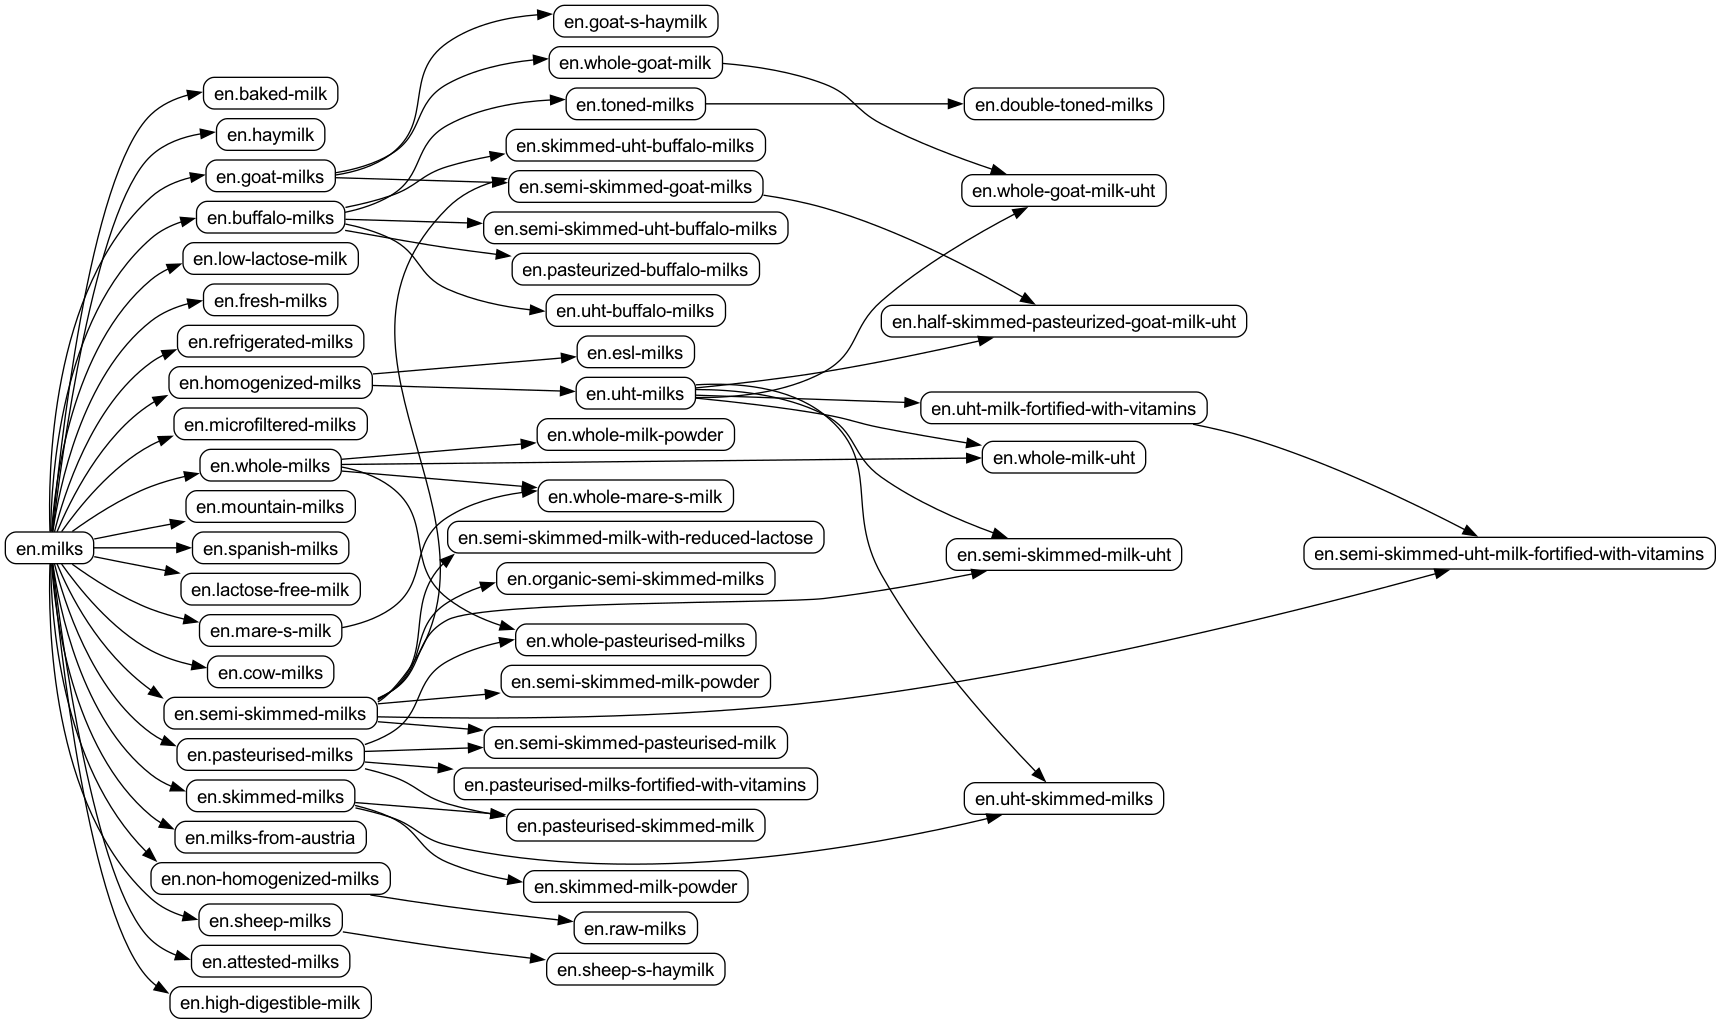

In [8]:
cat_name = 'en.milks'
descendants = nx.descendants(G, cat_name)

subG = G.subgraph(descendants | {cat_name})

# Set node style attributes
for node in subG.nodes:
    subG.nodes[node]['shape'] = 'box'
    subG.nodes[node]['style'] = 'rounded'


P = to_pydot(subG)
P.set('rankdir', 'LR') # left to right
P.set('nodesep', 0.1)
P.set('ranksep', 0.6)


for node in P.get_nodes():
    # node.set('fontsize', '10')
    node.set('fontname', 'Arial')
    node.set_height(0)
    # node.set('margin', '0.1,0.1')

Image(P.create_png())

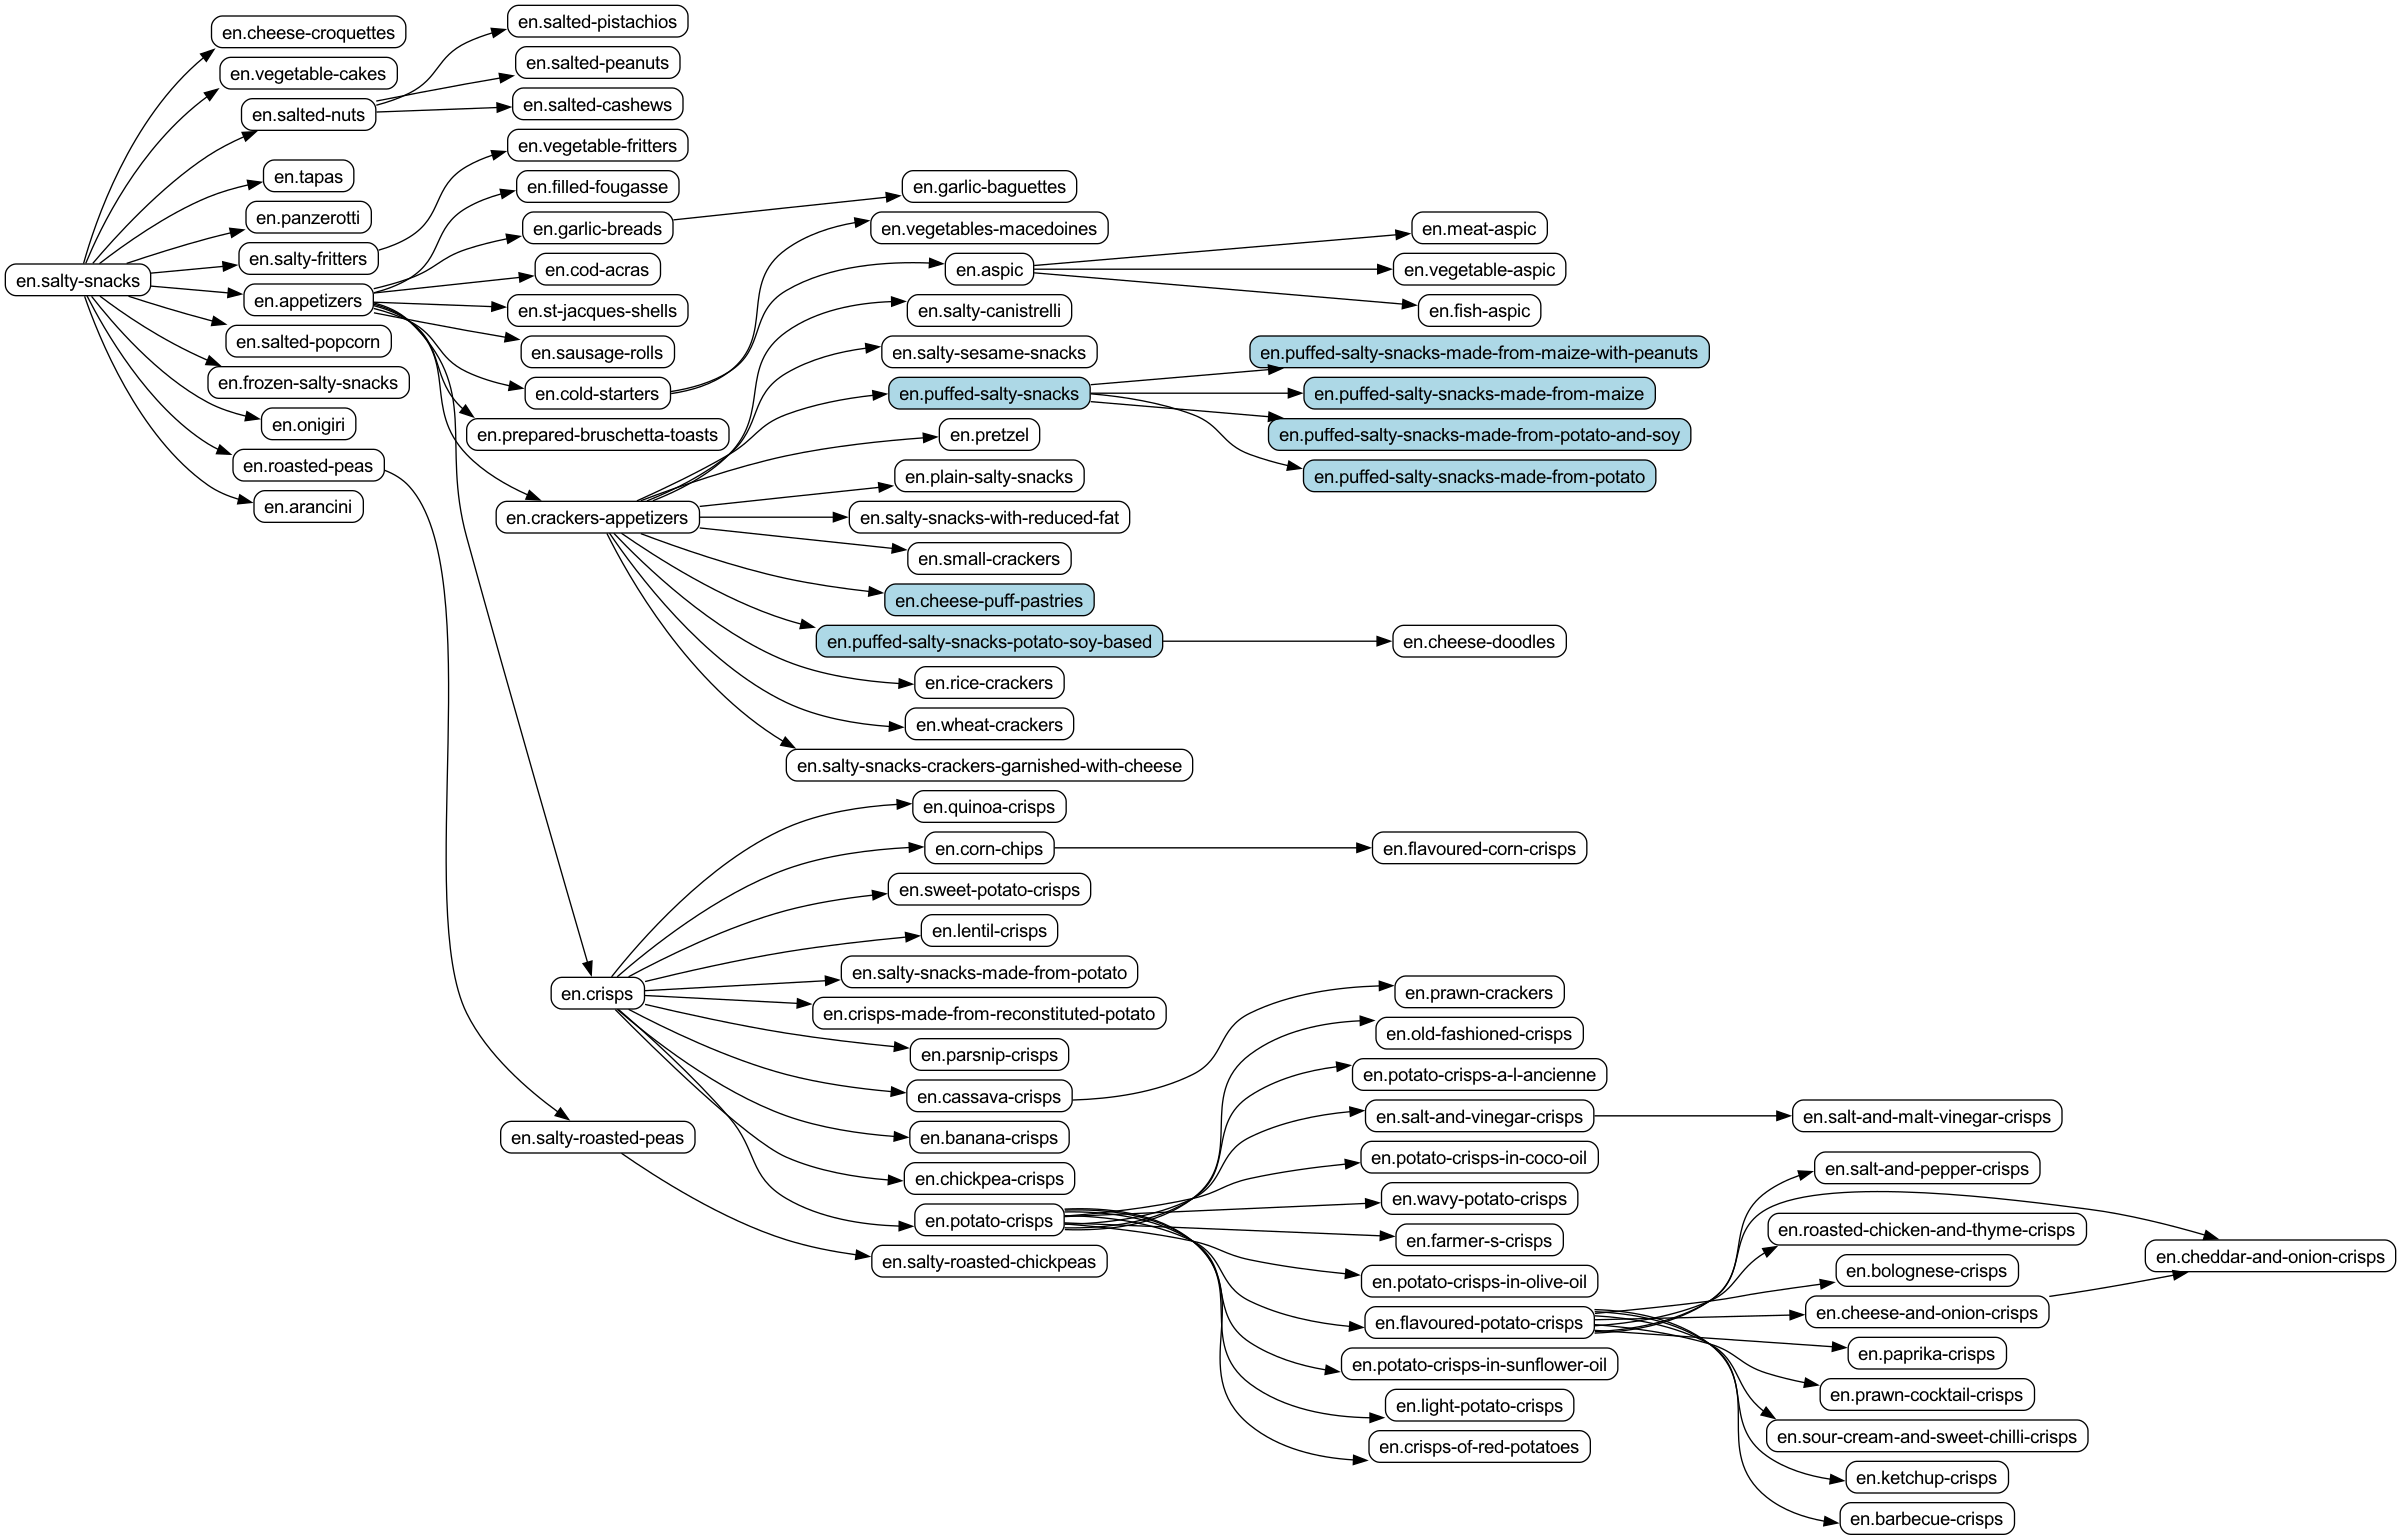

In [9]:
cat_name = 'en.salty-snacks'
descendants = nx.descendants(G, cat_name)

subG = G.subgraph(descendants | {cat_name})

# Set node style attributes
for node in subG.nodes:
    subG.nodes[node]['shape'] = 'box'
    subG.nodes[node]['style'] = 'rounded'


P = to_pydot(subG)
P.set('rankdir', 'LR') # left to right
P.set('nodesep', 0.1)
P.set('ranksep', 0.6)


for node in P.get_nodes():
    # node.set('fontsize', '10')
    node.set('fontname', 'Arial')
    node.set_height(0)
    # node.set('margin', '0.1,0.1')

    color = 'lightblue' if 'puff' in node.get_name() else 'white'
    node.set_style("rounded,filled")
    node.set('fillcolor', color)

#P.set_node_defaults(shape='box', style="rounded,filled")

P.write_png('salty-snacks.png')

Image(P.create_png())

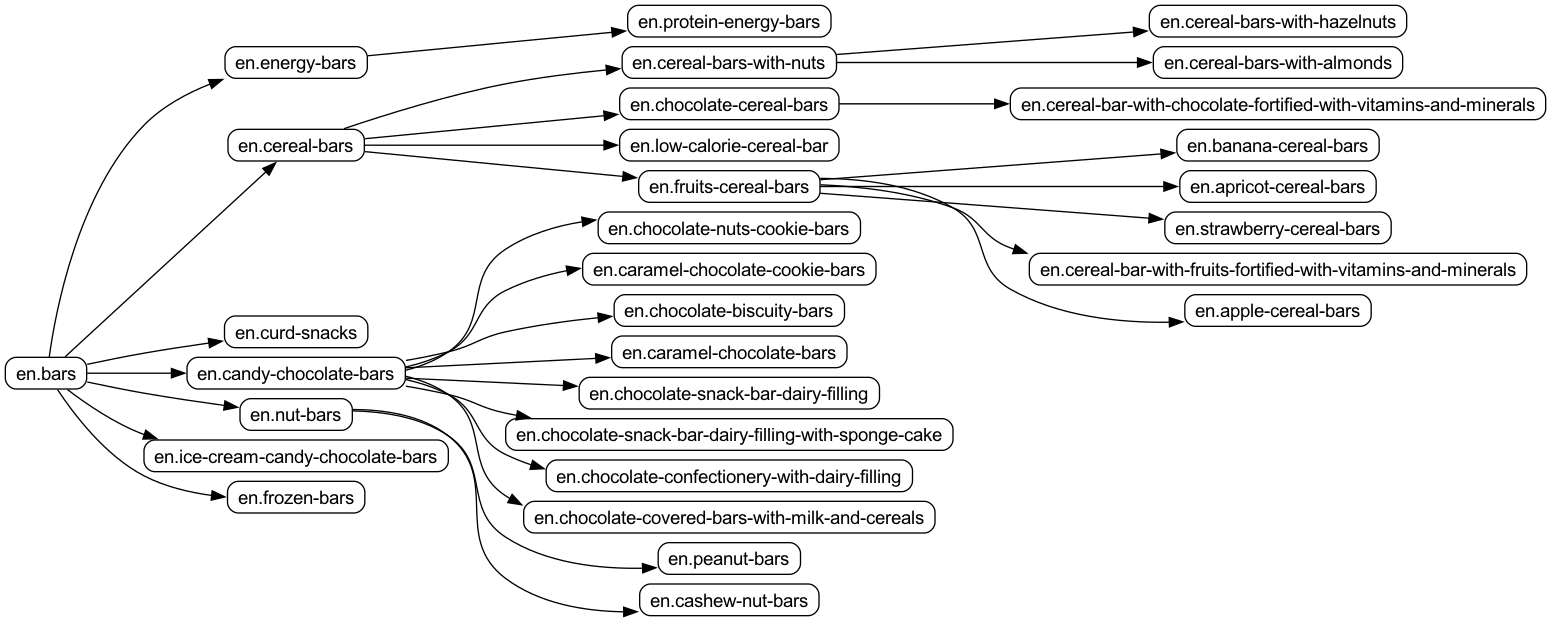

In [10]:
cat_name = 'en.bars'
descendants = nx.descendants(G, cat_name)

subG = G.subgraph(descendants | {cat_name})

# Set node style attributes
for node in subG.nodes:
    subG.nodes[node]['shape'] = 'box'
    subG.nodes[node]['style'] = 'rounded'


P = to_pydot(subG)
P.set('rankdir', 'LR') # left to right
P.set('nodesep', 0.1)
P.set('ranksep', 0.6)


for node in P.get_nodes():
    # node.set('fontsize', '10')
    node.set('fontname', 'Arial')
    node.set_height(0)
    # node.set('margin', '0.1,0.1')

Image(P.create_png())